# Lista Prática - Questão 3 - a, b, c

In [1]:
from examples.seismic.source import RickerSource, TimeAxis
from examples.seismic import setup_geometry, PointSource, Receiver, plot_velocity
from examples.seismic import SeismicModel, AcquisitionGeometry
from examples.seismic.stiffness.model import ISOSeismicModel
from examples.seismic.stiffness.utils import C_Matrix, D, S, vec
from devito import *
from examples.seismic.stiffness import iso_elastic_setup
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
from devito import configuration, norm
from IPython.display import display, display_html, HTML

configuration['log-level'] = 'WARNING'

%matplotlib inline

mpi4py is not available. You must install it


# Preparação do ambiente

## Parâmetros dos operadores de diferenças finitas

In [2]:
space_order=8
time_order=2

## Definição do modelo

### Dimensões do modelo

O modelo possui dimensões $w \times h = 1500 \mathrm{m} \times 1500 \mathrm{m}$, e um espaçamento de $\Delta x = \Delta z = 5$ m. Logo, a malha deverá ter 
$$
n_x = \frac{w}{\Delta x} + 1 = \frac{1500 \mathrm{m}}{5 \mathrm{m}} + 1 = 301
$$
pontos ao longo do eixo x, e
$$
n_z = \frac{h}{\Delta z} + 1 = \frac{1500 \mathrm{m}}{5 \mathrm{m}} + 1 = 301
$$
pontos ao longo do eixo z.

In [3]:
# shape = (151, 151)
shape = (301, 301)
# spacing = (10, 10)
spacing = (5, 5)
origin = (0., 0.)
# nbl=325
nbl=100

### Parâmetros físicos

O modelo possui uma única camada cuja velocidade de propagação das ondas P e S são respectivamente $v_P = 2$ $\mathrm{km/s}$ e $v_S = 1$ $\mathrm{km/s}$, e cuja densidade $\rho$ é $2$ $\mathrm{g/cm^3}$.

In [4]:
vp = 2.0 * np.ones(shape, dtype=np.float32) # Velocidade da onda P em km/s
vs = np.ones(shape, dtype=np.float32) # Velocidade da onda S em km/s
rho = 2.0 * np.ones(shape, dtype=np.float32) # Densidade em g/cm^3

In [5]:
model = ISOSeismicModel(vp=vp, vs=vs, b=1/rho, origin=origin, shape=shape, spacing=spacing,
              space_order=space_order, nbl=nbl, bcs="damp")

In [6]:
def plot_model(model, source=None, receiver=None, colorbar=True, cmap="jet"):
    """
    Esta função exibe os perfis de velocidade da onda P e densidade.
    """
    domain_size = 1.e-3 * np.array(model.domain_size)
    origin = 1.e-3 * np.array(model.origin)
    extent = [origin[0], origin[0] + domain_size[0],
              origin[1] + domain_size[1], origin[1]]

    slices = tuple(slice(model.nbl, -model.nbl) for _ in range(2))

    fig, axes = plt.subplots(1,3, figsize=(22,5))
    ax_vp = axes[0]
    ax_vs = axes[1]
    ax_rho = axes[2]
    
    vp = model.vp.data[slices]
    vs = model.vs.data[slices]
    rho = 1/model.b.data[slices]

    plot_vp = ax_vp.imshow(np.transpose(vp), animated=True, cmap='jet',
                      vmin=np.min(vp), vmax=np.max(vp),
                      extent=extent)
    ax_vp.set_xlabel('X position (km)')
    ax_vp.set_ylabel('Depth (km)')
    

    plot_vs = ax_vs.imshow(np.transpose(vs), animated=True, cmap='magma',
                      vmin=np.min(vs), vmax=np.max(vs),
                      extent=extent)
    ax_vs.set_xlabel('X position (km)')
    # ax_vp.set_ylabel('Depth (km)')


    plot_rho = ax_rho.imshow(np.transpose(rho), animated=True, cmap='cividis',
                      vmin=np.min(rho), vmax=np.max(rho),
                      extent=extent)
    ax_rho.set_xlabel('X position (km)')
    # ax_vp.set_ylabel('Depth (km)')


    for ax in axes:
        # Plot source points, if provided
        if receiver is not None:
            ax.scatter(1e-3*receiver[:, 0], 1e-3*receiver[:, 1],
                        s=25, c='green', marker='D')

        # Plot receiver points, if provided
        if source is not None:
            ax.scatter(1e-3*source[:, 0], 1e-3*source[:, 1],
                        s=25, c='red', marker='o')
        
        # Ensure axis limits
        ax.set_xlim(origin[0], origin[0] + domain_size[0])
        ax.set_ylim(origin[1] + domain_size[1], origin[1])


    # Create aligned colorbar on the right
    if colorbar:
        divider = make_axes_locatable(ax_vp)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(plot_vp, cax=cax)
        cbar.set_label('P Velocity (km/s)')
        
        divider = make_axes_locatable(ax_vs)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(plot_vs, cax=cax)
        cbar.set_label('S Velocity (km/s)')

        divider = make_axes_locatable(ax_rho)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(plot_rho, cax=cax)
        cbar.set_label('Density (g/cm$^3$)')

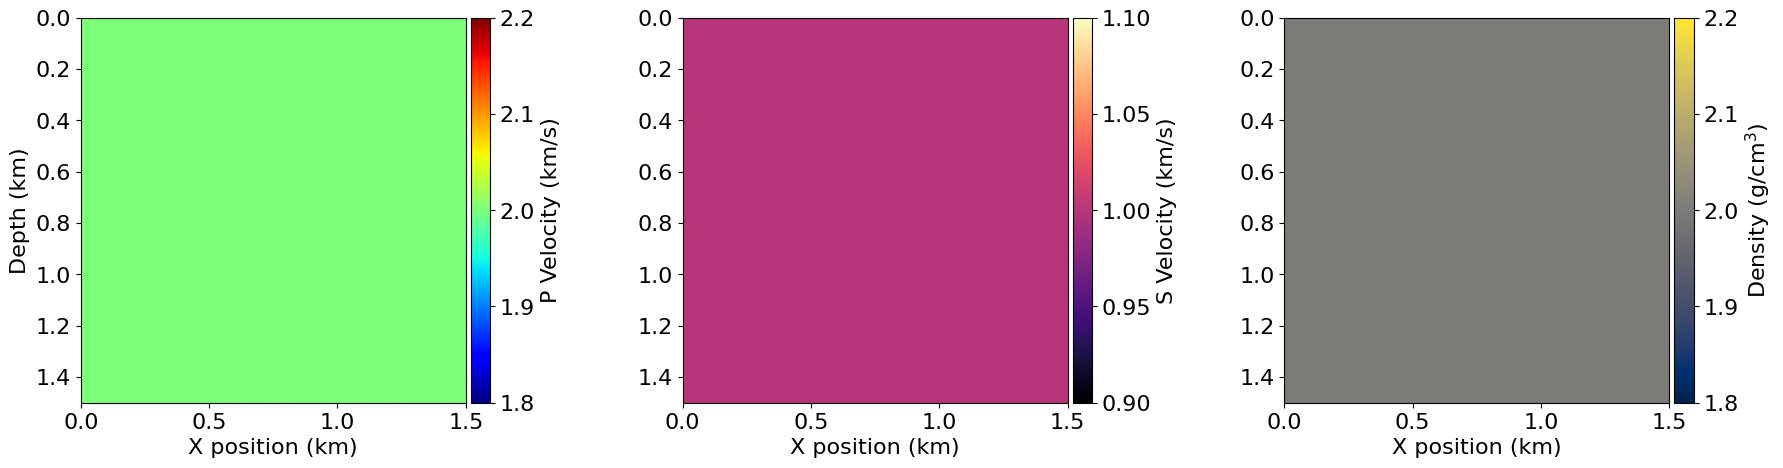

In [7]:
plot_model(model)

## Parâmetros da aquisição

### Tempo de aquisição

O período de aquisição inicia em $t_0 = 0$ $\mathrm{ms}$ e termina em $t_n = 2000$ $\mathrm{ms}$. O comprimento do passo temporal, $\Delta t$, foi escolhido como o $\Delta t_{\text{crítico}}$ que, embora tenha sido calculado por outro método, satisfaz a condição de estabilidade:
$$
\Delta t \le \frac{1}{\max(v_P)\sqrt{\dfrac{1}{\Delta x^2} + \dfrac{1}{\Delta z^2}}}
$$

In [8]:
t0 = 0.  # ms
tn = 2000. # ms
dt = model.critical_dt

time_range = TimeAxis(start=t0, stop=tn, step=dt)

### Geometria

Como o valor mínimo do campo de velocidade é $2.0\ \mathrm{km/s}$, o espaçamento do modelo é $\Delta x = \Delta z = 10 \mathrm{m}$ e a ordem do operador de diferenças finitas para as derivadas espaciais é igual a $8$ ($F = 4$), a frequência máxima $f_{\mathrm{max}}$ da onda propagada deve satisfazer
$$
\begin{aligned}
f_{\mathrm{max}} &\le \frac{\min{v_P}}{F\max{\Delta x, \Delta z}}\\
    &= \frac{2.0\ \mathrm{km/s}}{4 \times 10\ \mathrm{m}}\\
    &= 0.05\ \mathrm{kHz}
\end{aligned}
$$
A assinatura da fonte será a fonte de Ricker, que possui uma frequência de pico $f_{\mathrm{peak}} \approx \dfrac{1}{3} f_{\mathrm{max}}$. Com base nisto, foi escolhida uma frequência máxima de $0.048\ \mathrm{kHz}$, resultando numa frequência de pico igual a $0.016\ \mathrm{kHz}$.

In [9]:
# Frequência de pico da fonte
f0 = 0.016

In [10]:
zero_coords = np.array([[0,0]], dtype=model.dtype) # Para zerar as coordenadas da fonte e dos receptores da geometria.
geometry = AcquisitionGeometry(model, zero_coords, zero_coords, t0, tn)
geometry.resample(dt)

time_range = geometry.time_axis

A fonte está posicionada no centro do modelo.

In [11]:
src = RickerSource(name='src', grid=model.grid, f0=f0,
                   npoint=1, time_range=time_range)

src.coordinates.data[0, :] = np.array(model.domain_size) * .5

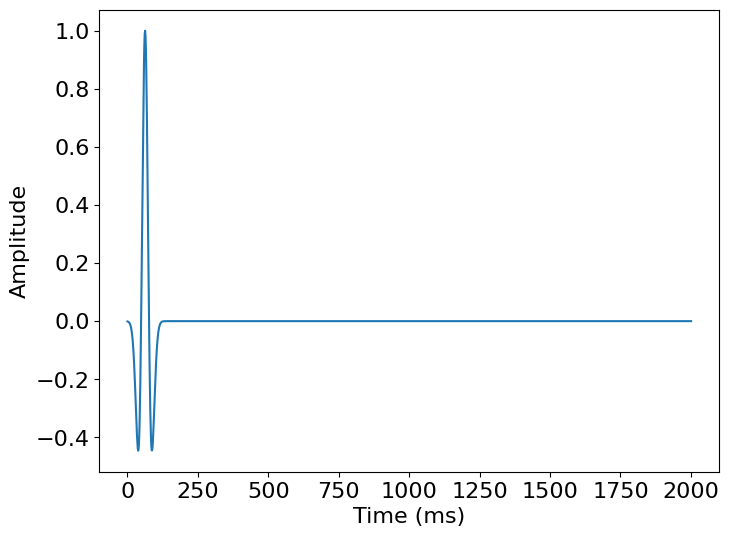

In [12]:
src.show() # Assinatura da fonte

Como apenas a pressão será registrada, basta criar um único receptor para ler o campo $\tau_{xx}$ ou $\tau_{zz}$, pois, para em um regime de pressão hidroestática, $\tau_{xx} = \tau_{zz} = -P$. Neste caso, foi escolhido o campo $\tau_{xx}$.

In [13]:
rec = Receiver(name='rec', grid=model.grid, time_range=time_range, npoint=shape[0])

rec.coordinates.data[:, 0] = np.linspace(model.origin[0], model.domain_size[0], dtype=model.dtype, num=shape[0])
rec.coordinates.data[:, 1] = spacing[1]


#### Posição da fonte

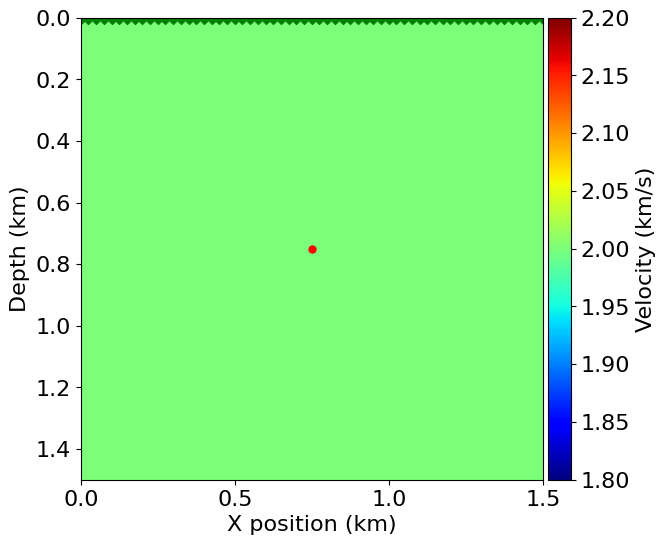

In [14]:
plot_velocity(model, source=src.coordinates.data, receiver=rec.coordinates.data[::5])

# Resolução da alternativa a)

### Definição da equação da onda elástica de 2ª ordem

Aqui é definida no *Devito* a equação

$$
\rho\frac{\partial^2 \mathbf{u}}{\partial t^2} - DCD^T\mathbf{u} = \mathbf{S}
$$

em que:

- $\mathbf{u}$ é o campo de deslocamento de partícula;
- $C$ é a matriz de rigidez;
- $D$ é a matriz de derivadas espaciais;
- $\mathbf{S}$ é o termo fonte;

In [15]:
C = C_Matrix(model,'vp-vs-rho')

In [16]:
# tau = vec(TensorTimeFunction(name='tau', grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt))
# v = VectorTimeFunction(name='v', grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt)
u = VectorTimeFunction(name='u', grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt, staggered=[NODE, NODE])

In [17]:
# Equações da onda elástica de 2ª ordem
EDP = model.rho * u.dt2 - D(C*S(u))

In [18]:
# Expressão para o campo de ondas futuro, P(r, t + dt)

stencil = Eq(u.forward, solve(EDP, u.forward))
stencil

Eq(Vector(u_x(time + dt, x, y), u_y(time + dt, x, y)), Vector(dt**2*(-rho*(-2.0*u_x(time, x, y)/dt**2 + u_x(time - dt, x, y)/dt**2) + Derivative(rho*(Derivative(u_x(time, x, y), y) + Derivative(u_y(time, x, y), x))*vs(x, y)**2, y) + Derivative(rho*vp(x, y)**2*Derivative(u_x(time, x, y), x) + (rho*vp(x, y)**2 - 2*rho*vs(x, y)**2)*Derivative(u_y(time, x, y), y), x))/rho, dt**2*(-rho*(-2.0*u_y(time, x, y)/dt**2 + u_y(time - dt, x, y)/dt**2) + Derivative(rho*(Derivative(u_x(time, x, y), y) + Derivative(u_y(time, x, y), x))*vs(x, y)**2, x) + Derivative(rho*vp(x, y)**2*Derivative(u_y(time, x, y), y) + (rho*vp(x, y)**2 - 2*rho*vs(x, y)**2)*Derivative(u_x(time, x, y), x), y))/rho))

Com base na expressão acima para o campo $\mathbf{u}(\mathbf{x}, t + \Delta t)$, observa-se que o termo fonte possui um coeficiente igual a $\rho\Delta t^2$. Logo, a fonte $S$ deve ser injetada no campo de ondas futuro como $\rho\Delta t^2 S(\mathbf{x}, t)$.

In [19]:
# Símbolo do espaçamento temporal
s = model.grid.stepping_dim.spacing

# Expressão do termo fonte a ser injetada no stencil criado acima
src_term_xx = src.inject(u[0].forward, expr = 1/model.rho * s**2 * src)
src_term_zz = src.inject(u[1].forward, expr = 1/model.rho * s**2 * src)

src_term = src_term_xx + src_term_zz

Sob um regime de pressão hidrostática, basta ler ou o campo $\tau_{xx}$ ou o campo $\tau_{zz}$, pois $\tau_{xx} = \tau_{zz} = -P$. Neste caso, será lido o campo $\tau_{xx}$.

In [20]:
# Expressão do termo dos receptores que amostrarão o campo de ondas
rec_term = rec.interpolate(expr=u[0].forward)

### Criação do operador de diferenças finitas

In [21]:
# Criação do operador do Devito
op = Operator([stencil] + src_term + rec_term, subs=model.spacing_map)

In [22]:
# Execução
op(dt=dt)

PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=6.174560999999995, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section1', rank=None),
                     PerfEntry(time=0.0023539999999999993, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section2', rank=None),
                     PerfEntry(time=0.020494999999999975, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

### Plotagem do campo de ondas

In [23]:
def plot_wavefield(u, geometry, src_pos, model, title=None, t0=0, tn=-1, rec_pos=None):
    """
    Exibe o campo de onda em 4 instantes distribuídos em um período determinado por `t0` e `tn`
    """
    shape_pad = np.array(model.shape)
    origin_pad = origin
    extent_pad = tuple([s*(n-1) for s, n in zip(spacing, shape_pad)])

    # Note: flip direction of second dimension to make the plot positive downwards
    plt_extent = [origin_pad[0], origin_pad[0] + extent_pad[0],
                origin_pad[1] + extent_pad[1], origin_pad[1]]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)
    fig.suptitle(title, size=20, y=1.05)
    isfirst = True
    last_ax = None
    last_plot = None

    t0 = t0 - geometry.t0
    tn = tn - geometry.t0

    snapshots = None
    if tn < 0:
        idx_min = max(int(np.round(t0/dt)), 0)
        snapshots = np.linspace(idx_min, geometry.nt - 1, num=4, dtype=np.int32)
    else:
        idx_min = max(int(np.round(t0/dt)), 0)
        idx_max = min(int(np.round(tn/dt)), geometry.nt - 1)
        snapshots = np.linspace(idx_min, idx_max, num=4, dtype=np.int32)


    udata = u.data
    amax = np.max(np.abs(udata[geometry.nt-1, :, :]))

    for count, ax in enumerate(axes.ravel()):
        snapshot = snapshots[count]
        last_plot = ax.imshow(udata[snapshot, model.nbl:-model.nbl, model.nbl:-model.nbl].T,
                              cmap="seismic", vmin=-amax,
                  vmax=+amax, extent=plt_extent)
        ax.plot(src_pos[0], src_pos[1], 'red', linestyle='None', marker='*',
                markersize=8, label="Source")
        
        if type(rec_pos) != type(None):
            ax.plot(rec_pos[0], rec_pos[1], 'green', linestyle='None', marker='v',
                    markersize=8, label="Receiver")
            
        ax.grid()
        ax.tick_params('both', length=4, width=0.5, which='major', labelsize=11)

        ax.set_title("t=%.2fms" % (snapshot*dt + geometry.t0), fontsize=12)
        ax.set_xlabel("x (m)", fontsize=12)
        isfirst and ax.set_ylabel("z (m)", fontsize=12)
        isfirst = False
        last_ax = ax
    
    divider = make_axes_locatable(last_ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(last_plot, cax=cax)

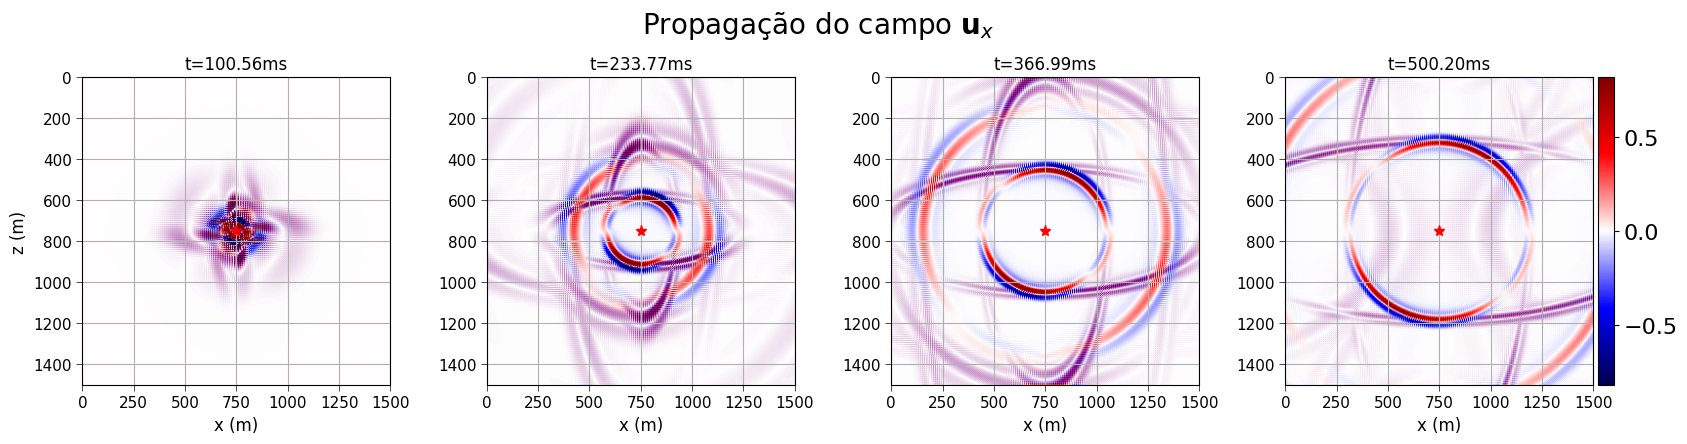

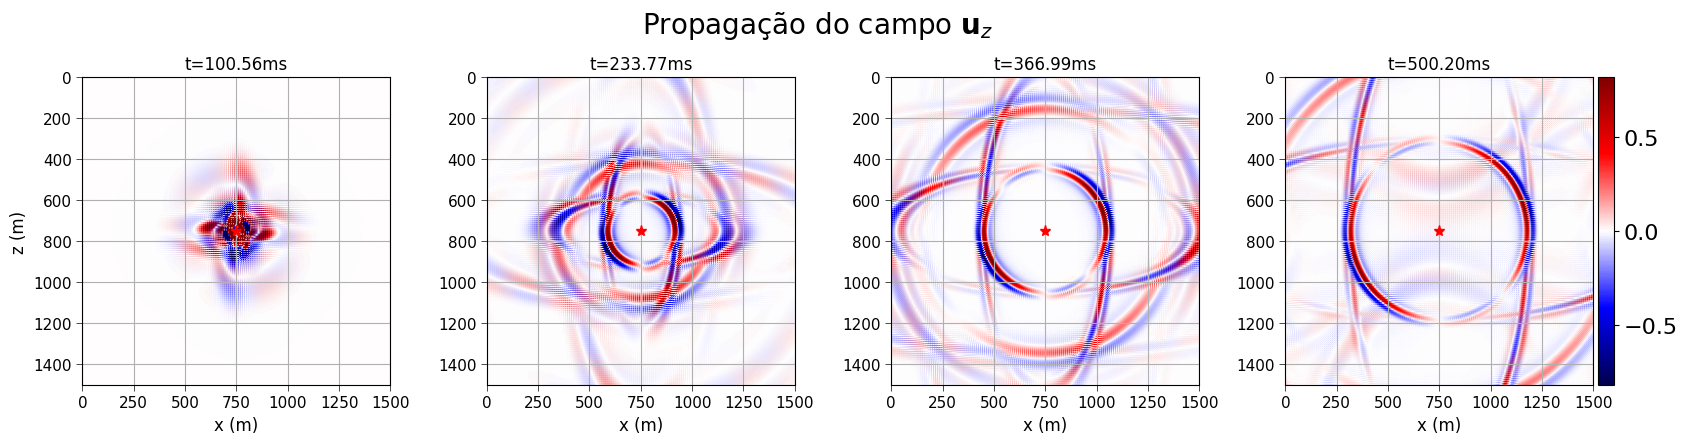

In [ ]:
plot_wavefield(u[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $u_{x}$', t0=100, tn=500)
plot_wavefield(u[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $u_{z}$', t0=100, tn=500)

In [27]:
def plot_animated_wavefield(u, geometry, src_pos, model, title=None, t0=0, tn=-1, rec_pos=None, nframes=10):
    """
    Reproduz uma animação do campo de ondas se propagando.
    """
    shape_pad = np.array(model.shape)
    origin_pad = origin
    extent_pad = tuple([s*(n-1) for s, n in zip(spacing, shape_pad)])

    # Note: flip direction of second dimension to make the plot positive downwards
    plt_extent = [origin_pad[0], origin_pad[0] + extent_pad[0],
                origin_pad[1] + extent_pad[1], origin_pad[1]]
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 5), sharex=True)
    # fig.suptitle(title, size=20, y=1.05)

    t0 = t0 - geometry.t0
    tn = tn - geometry.t0

    snapshots = None
    if tn < 0:
        idx_min = max(int(np.round(t0/dt)), 0)
        snapshots = np.linspace(idx_min, geometry.nt - 1, num=nframes, dtype=np.int32)
    else:
        idx_min = max(int(np.round(t0/dt)), 0)
        idx_max = min(int(np.round(tn/dt)), geometry.nt - 1)
        snapshots = np.linspace(idx_min, idx_max, num=nframes, dtype=np.int32)


    udata = u.data
    amax = np.max(np.abs(udata[geometry.nt-1, :, :]))
    
    snapshot = snapshots[0]
    wave_plot = ax.imshow(udata[snapshot, model.nbl:-model.nbl, model.nbl:-model.nbl].T,
                            cmap="seismic", vmin=-amax,
                vmax=+amax, extent=plt_extent)
    ax.plot(src_pos[0], src_pos[1], 'red', linestyle='None', marker='*',
            markersize=8, label="Source")
    
    if type(rec_pos) != type(None):
        ax.plot(rec_pos[0], rec_pos[1], 'green', linestyle='None', marker='v',
                markersize=8, label="Receiver")
        
    nbl_color = 'xkcd:dark blue'
    time_text = ax.text(
        plt_extent[0] + (plt_extent[2] - plt_extent[0])*0.05, 
        plt_extent[1] + (plt_extent[3] - plt_extent[1])*0.05
    , 't=...', color=nbl_color)
    ax.set_title(title)


    ax.grid()
    ax.tick_params('both', length=4, width=0.5, which='major', labelsize=11)

    ax.set_xlabel("x (m)", fontsize=12)
    ax.set_ylabel("z (m)", fontsize=12)
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(wave_plot, cax=cax)

    def update(snapshot):
        wave_plot.set_array(udata[snapshot, model.nbl:-model.nbl, model.nbl:-model.nbl].T)
        time_text.set_text("t=%.2fms" % (snapshot*dt + geometry.t0))

    anim = animation.FuncAnimation(fig, update, frames=snapshots, blit=False)

    plt.close(fig)
    display(HTML(anim.to_jshtml()))

In [ ]:
plot_animated_wavefield(u[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $u_{x}$', nframes=30)
plot_animated_wavefield(u[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $u_{z}$', nframes=30)
# plot_animated_wavefield(tau[2], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{xz}$', nframes=30)

# plot_animated_wavefield(v[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $V_{x}$', nframes=30)
# plot_animated_wavefield(v[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $V_{z}$', nframes=30)

TypeError: The object must be a Tensor object